# Práctica 2: Segmentación Semántica (De lo General a lo Clínico)

**Asignatura:** Aprendizaje Automático III (IN1042)
**Contexto del Caso Transversal (Behe):** Aislamiento de la red vascular retiniana.

## 1. Contexto Clínico y Ético
En la Práctica 1 abordamos la **clasificación de imágenes**, donde nuestra red neuronal convolucional (CNN) respondía a la pregunta: *"¿Este paciente tiene retinopatía diabética o no?"*. Sin embargo, en el entorno de la tecnología médica de precisión (como las soluciones que desarrollamos para Behe), una clasificación global suele ser insuficiente.

Los oftalmólogos requieren herramientas de **Segmentación Semántica**. La segmentación no asigna una etiqueta a toda la imagen, sino que clasifica **cada píxel individualmente**. Esto nos permite aislar estructuras anatómicas específicas, como tumores, la copa óptica o, en nuestro caso, la red de vasos sanguíneos del fondo del ojo.

### El Puente Pedagógico (Dataset Seguro)
Trabajar con imágenes médicas crudas en entornos de laboratorio a veces conlleva problemas de compatibilidad de formatos (DICOM) o pesos excesivos. Para garantizar el éxito de la arquitectura y centrarnos en la ingeniería del modelo, hoy construiremos un *pipeline* de segmentación semántica utilizando el dataset estándar **Oxford-IIIT Pets**.

**Analítica Clínica:**
*   **Fondo (Background):** En Behe, esto representa el tejido sano de la retina.
*   **Sujeto (Foreground):** Aquí serán las mascotas; en Behe, representa los vasos sanguíneos o las lesiones.
*   **Contorno (Boundaries):** Las zonas de transición.

La arquitectura *Encoder-Decoder* que programaremos hoy es matemáticamente idéntica a la que se utiliza en la industria para el análisis del fondo de ojo.

# ENCODER - DECODER

## Librerias y verificación de GPU

In [1]:
import os

# PyTorch puro usará CUDA para aprovechar la GPU NVIDIA en Windows
os.environ["KERAS_BACKEND"] = "torch"

import gc
import pathlib
import random
import tarfile
import urllib.request

import keras
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from keras import layers
from keras.layers import Conv2D, Rescaling
from keras.utils import array_to_img, img_to_array, load_img
from torch.utils.data import DataLoader, TensorDataset

print("--- Auditoría de Hardware ---")
print("¿PyTorch detecta la GPU NVIDIA?:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Tarjeta Gráfica detectada:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo de entrenamiento:", device)

print("\n--- Verificación de Entorno Multi-Backend (Keras 3) ---")
print("Versión de Keras:", keras.__version__)
print("Motor (Backend) activo en Keras:", keras.backend.backend())

--- Auditoría de Hardware ---
¿PyTorch detecta la GPU NVIDIA?: True
Tarjeta Gráfica detectada: NVIDIA GeForce RTX 4050 Laptop GPU
Dispositivo de entrenamiento: cuda

--- Verificación de Entorno Multi-Backend (Keras 3) ---
Versión de Keras: 3.15.1
Motor (Backend) activo en Keras: torch


## Descarga de dataset

In [2]:
from pathlib import Path
import urllib.request
import tarfile

images_dir = Path("images")
annotations_dir = Path("annotations")

if images_dir.exists() and annotations_dir.exists():
    print("Los datos ya existen. No se descargan otra vez.")
else:
    urls = {
        "images.tar.gz": "https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz",
        "annotations.tar.gz": "https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz",
    }

    for filename, url in urls.items():
        path = Path(filename)

        if not path.exists():
            print(f"Descargando {filename}...")
            urllib.request.urlretrieve(url, path)

        print(f"Descomprimiendo {filename}...")
        with tarfile.open(path, "r:gz") as tar:
            tar.extractall()

    print("Datos listos.")

Los datos ya existen. No se descargan otra vez.


In [3]:
input_dir = pathlib.Path("images")
target_dir = pathlib.Path("annotations/trimaps")

input_img_paths = sorted(input_dir.glob("*.jpg"))
# Ignores some spurious files in the trimaps directory that start with
# a "."
target_paths = sorted(target_dir.glob("[!.]*.png"))

In [4]:
print(f"input_dir : {input_dir}")
print(f"target_dir : {target_dir}")
print(f"input_img_paths : {input_img_paths}")
print(f"target_paths : {target_paths}")

input_dir : images
target_dir : annotations\trimaps
input_img_paths : [WindowsPath('images/Abyssinian_1.jpg'), WindowsPath('images/Abyssinian_10.jpg'), WindowsPath('images/Abyssinian_100.jpg'), WindowsPath('images/Abyssinian_101.jpg'), WindowsPath('images/Abyssinian_102.jpg'), WindowsPath('images/Abyssinian_103.jpg'), WindowsPath('images/Abyssinian_104.jpg'), WindowsPath('images/Abyssinian_105.jpg'), WindowsPath('images/Abyssinian_106.jpg'), WindowsPath('images/Abyssinian_107.jpg'), WindowsPath('images/Abyssinian_108.jpg'), WindowsPath('images/Abyssinian_109.jpg'), WindowsPath('images/Abyssinian_11.jpg'), WindowsPath('images/Abyssinian_110.jpg'), WindowsPath('images/Abyssinian_111.jpg'), WindowsPath('images/Abyssinian_112.jpg'), WindowsPath('images/Abyssinian_113.jpg'), WindowsPath('images/Abyssinian_114.jpg'), WindowsPath('images/Abyssinian_115.jpg'), WindowsPath('images/Abyssinian_116.jpg'), WindowsPath('images/Abyssinian_117.jpg'), WindowsPath('images/Abyssinian_118.jpg'), WindowsPa

In [5]:
print(f"Número de imágenes : {len(input_img_paths)}")
print(f"Número de etiquetas : {len(target_paths)}")

Número de imágenes : 7390
Número de etiquetas : 7390


## Visualización de Dataset

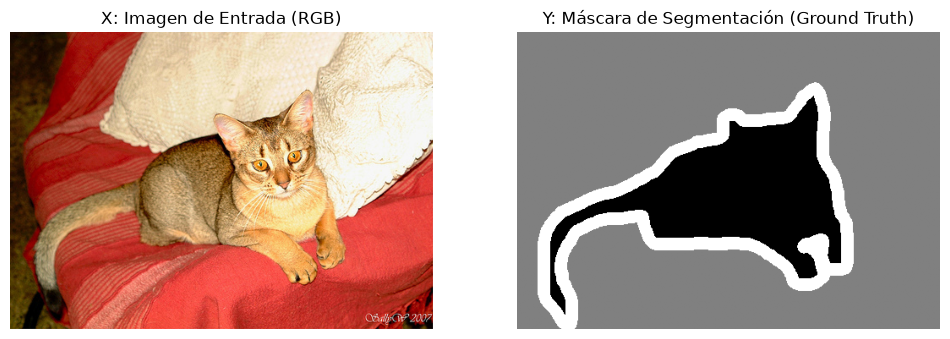

Valores únicos presentes en el tensor de la máscara: [1. 2. 3.]


In [6]:
# Seleccionamos una imagen aleatoria para el análisis visual
index = 5

# 1. Mostrar la imagen original
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("X: Imagen de Entrada (RGB)")
plt.imshow(load_img(input_img_paths[index]))

# 2. Mostrar la máscara objetivo (Ground Truth)
# Función auxiliar para mejorar el contraste de la máscara en matplotlib
def display_target(target_array):
    # Restamos 1 (para que los valores sean 0, 1, 2) y multiplicamos por 127
    # para empujar los valores al rango visible (0, 127, 254) en escala de grises.
    normalized_array = (target_array.astype("uint8") - 1) * 127
    plt.imshow(normalized_array[:, :, 0], cmap='gray')

# Cargamos la máscara obligando a que sea en escala de grises (un solo canal)
img_target = img_to_array(load_img(target_paths[index], color_mode="grayscale"))

plt.subplot(1, 2, 2)
plt.axis("off")
plt.title("Y: Máscara de Segmentación (Ground Truth)")
display_target(img_target)
plt.show()

# Verificación de valores únicos en el tensor de la máscara
print("Valores únicos presentes en el tensor de la máscara:", np.unique(img_target))

## Preparar dataset

In [7]:
# Definición de tamaño y conteo de muestras
img_size = (200, 200)
num_imgs = len(input_img_paths)

# Aleatorización de rutas manteniendo correspondencia exacta de parejas (X, Y)
random.Random(1337).shuffle(input_img_paths)
random.Random(1337).shuffle(target_paths)

In [8]:
def path_to_input_image(path):
    """Carga la imagen de entrada en color RGB y la convierte a arreglo NumPy."""
    return img_to_array(load_img(path, target_size=img_size))

def path_to_target(path):
    """Carga la máscara objetivo en escala de grises y ajusta las etiquetas a [0, 1, 2]."""
    img = img_to_array(
        load_img(path, target_size=img_size, color_mode="grayscale")
    )
    img = img.astype("uint8") - 1
    return img

In [9]:
# Inicialización de tensores NumPy vacíos
input_imgs = np.zeros((num_imgs,) + img_size + (3,), dtype="float32")
targets = np.zeros((num_imgs,) + img_size + (1,), dtype="uint8")

print("--- Cargando dataset completo a tensores NumPy ---")
for i in range(num_imgs):
    input_imgs[i] = path_to_input_image(input_img_paths[i])
    targets[i] = path_to_target(target_paths[i])

print(f"Tensor de Entradas (X): {input_imgs.shape}, tipo: {input_imgs.dtype}")
print(f"Tensor de Objetivos (Y): {targets.shape}, tipo: {targets.dtype}")

--- Cargando dataset completo a tensores NumPy ---
Tensor de Entradas (X): (7390, 200, 200, 3), tipo: float32
Tensor de Objetivos (Y): (7390, 200, 200, 1), tipo: uint8


In [10]:
# Partición de datos: Reservamos 1,000 muestras para validación
num_val_samples = 1000

train_input_imgs = np.ascontiguousarray(input_imgs[:-num_val_samples])
train_targets = np.ascontiguousarray(targets[:-num_val_samples])
val_input_imgs = np.ascontiguousarray(input_imgs[-num_val_samples:])
val_targets = np.ascontiguousarray(targets[-num_val_samples:])

print(f"\nMuestras para entrenamiento: {len(train_input_imgs)}")
print(f"Muestras para validación: {len(val_input_imgs)}")
print("Entradas contiguas:", train_input_imgs.flags["C_CONTIGUOUS"])
print("Targets contiguos:", train_targets.flags["C_CONTIGUOUS"])


Muestras para entrenamiento: 6390
Muestras para validación: 1000
Entradas contiguas: True
Targets contiguos: True


## Definición de arquitectura del modelo y compilación

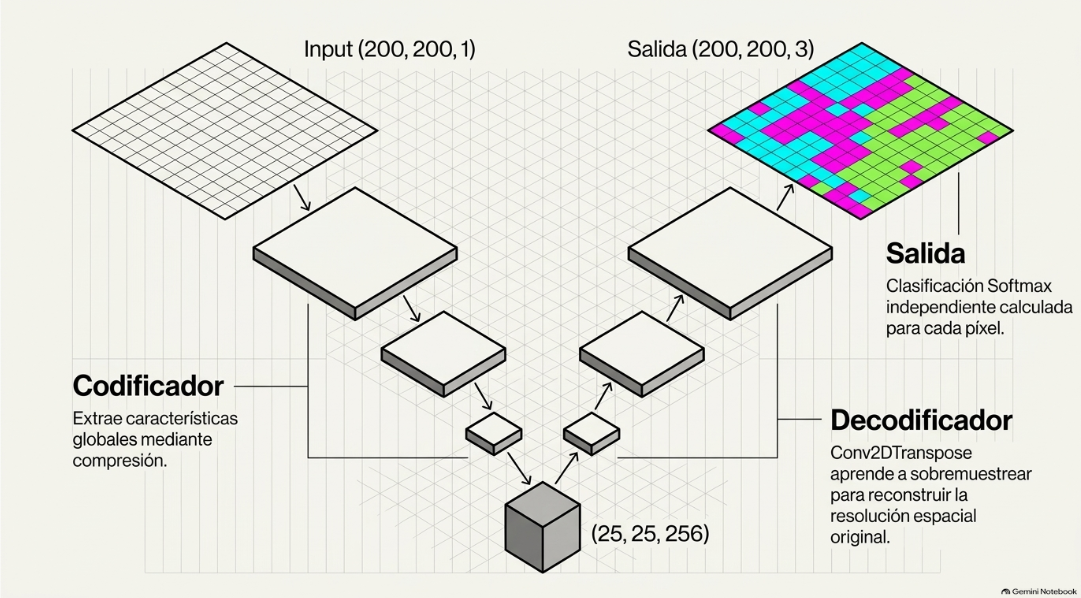

In [11]:
class EncoderDecoderSegmentation(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(64, num_classes, kernel_size=3, padding=1),
        )

    def forward(self, x):
        x = x.permute(0, 3, 1, 2).contiguous().float() / 255.0
        x = self.encoder(x)
        x = self.decoder(x)
        return x

img_size = (200, 200)
num_classes = 3

modelo_segmentacion = EncoderDecoderSegmentation(num_classes=num_classes).to(device)
print(modelo_segmentacion)
print("Parámetros entrenables:", sum(p.numel() for p in modelo_segmentacion.parameters() if p.requires_grad))

EncoderDecoderSegmentation(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Upsample(scale_factor=2.0, mode='nearest')
    (5): Conv2d(256, 128, kern

In [12]:
#no correr foreground_iou me trabó todo porque hacia que no se usara bien la gpu
#viene en el libro pero mejor no incluirla

foreground_iou = keras.metrics.IoU(
    # Specifies the total number of classes
    num_classes=3,
    # Specifies the class to compute IoU for (0 = foreground)
    target_class_ids=(0,),
    name="foreground_iou",
    # Our targets are sparse (integer class IDs).
    sparse_y_true=True,
    # But our model's predictions are a dense softmax!
    sparse_y_pred=False,
)


In [13]:
# Configuración de entrenamiento en PyTorch
model_path = "models/oxford_segmentation_pytorch.pt"
os.makedirs("models", exist_ok=True)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(modelo_segmentacion.parameters(), lr=1e-3)

print("Modelo listo para entrenar en:", device)

Modelo listo para entrenar en: cuda


## Entrenamiento del modelo

In [14]:
print("--- Iniciando entrenamiento con PyTorch en GPU ---")

batch_size = 16
epochs = 15

train_dataset = TensorDataset(
    torch.from_numpy(train_input_imgs),
    torch.from_numpy(train_targets.squeeze(-1)).long(),
)
val_dataset = TensorDataset(
    torch.from_numpy(val_input_imgs),
    torch.from_numpy(val_targets.squeeze(-1)).long(),
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}
best_val_loss = float("inf")

for epoch in range(epochs):
    modelo_segmentacion.train()
    train_loss = 0.0
    train_correct = 0
    train_pixels = 0

    for batch_imgs, batch_masks in train_loader:
        batch_imgs = batch_imgs.to(device, non_blocking=True)
        batch_masks = batch_masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = modelo_segmentacion(batch_imgs)
        loss = criterion(logits, batch_masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch_imgs.size(0)
        train_correct += (logits.argmax(dim=1) == batch_masks).sum().item()
        train_pixels += batch_masks.numel()

    modelo_segmentacion.eval()
    val_loss = 0.0
    val_correct = 0
    val_pixels = 0

    with torch.no_grad():
        for batch_imgs, batch_masks in val_loader:
            batch_imgs = batch_imgs.to(device, non_blocking=True)
            batch_masks = batch_masks.to(device, non_blocking=True)

            logits = modelo_segmentacion(batch_imgs)
            loss = criterion(logits, batch_masks)

            val_loss += loss.item() * batch_imgs.size(0)
            val_correct += (logits.argmax(dim=1) == batch_masks).sum().item()
            val_pixels += batch_masks.numel()

    epoch_loss = train_loss / len(train_dataset)
    epoch_acc = train_correct / train_pixels
    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = val_correct / val_pixels

    history["loss"].append(epoch_loss)
    history["accuracy"].append(epoch_acc)
    history["val_loss"].append(epoch_val_loss)
    history["val_accuracy"].append(epoch_val_acc)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(modelo_segmentacion.state_dict(), model_path)

    print(
        f"Epoch {epoch + 1}/{epochs} - "
        f"loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} - "
        f"val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}"
    )

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("Mejor modelo guardado en:", model_path)

--- Iniciando entrenamiento con PyTorch en GPU ---
Epoch 1/15 - loss: 0.8606 - accuracy: 0.6209 - val_loss: 0.7789 - val_accuracy: 0.6548
Epoch 2/15 - loss: 0.7103 - accuracy: 0.7158 - val_loss: 0.6771 - val_accuracy: 0.7270
Epoch 3/15 - loss: 0.6027 - accuracy: 0.7590 - val_loss: 0.5451 - val_accuracy: 0.7827
Epoch 4/15 - loss: 0.5204 - accuracy: 0.7940 - val_loss: 0.5191 - val_accuracy: 0.7983
Epoch 5/15 - loss: 0.4683 - accuracy: 0.8166 - val_loss: 0.4551 - val_accuracy: 0.8237
Epoch 6/15 - loss: 0.4314 - accuracy: 0.8318 - val_loss: 0.4348 - val_accuracy: 0.8332
Epoch 7/15 - loss: 0.4096 - accuracy: 0.8410 - val_loss: 0.4270 - val_accuracy: 0.8347
Epoch 8/15 - loss: 0.3995 - accuracy: 0.8450 - val_loss: 0.3956 - val_accuracy: 0.8492
Epoch 9/15 - loss: 0.3710 - accuracy: 0.8564 - val_loss: 0.4005 - val_accuracy: 0.8465
Epoch 10/15 - loss: 0.3568 - accuracy: 0.8618 - val_loss: 0.3706 - val_accuracy: 0.8584
Epoch 11/15 - loss: 0.3399 - accuracy: 0.8681 - val_loss: 0.3617 - val_accurac

In [15]:
#BORRO LA RAM DE LA GPU
gc.collect()
if keras.backend.backend() == "torch" and torch.cuda.is_available():
  torch.cuda.empty_cache()

## Predicciones con modelos entrenados

In [16]:
# Carga del mejor modelo guardado
model_path = "models/oxford_segmentation_pytorch.pt"
modelo_optimizado = EncoderDecoderSegmentation(num_classes=num_classes).to(device)
modelo_optimizado.load_state_dict(torch.load(model_path, map_location=device))
modelo_optimizado.eval()

print("Modelo PyTorch cargado desde:", model_path)

Modelo PyTorch cargado desde: models/oxford_segmentation_pytorch.pt


In [17]:
def visualizar_prediccion(i):
    """Muestra la imagen original, la máscara real y la máscara predicha por la red."""
    mask_predicha = np.argmax(predicciones[i], axis=-1)
    mask_predicha = np.expand_dims(mask_predicha, axis=-1)

    plt.figure(figsize=(14, 5))

    # Imagen original
    plt.subplot(1, 3, 1)
    plt.title("X: Imagen Entrada", fontweight="bold")
    plt.imshow(val_input_imgs[i].astype("uint8"))
    plt.axis("off")

    # Máscara Real
    plt.subplot(1, 3, 2)
    plt.title("Y: Ground Truth", fontweight="bold")
    plt.imshow(val_targets[i] * 127, cmap="gray")
    plt.axis("off")

    # Máscara Predicha
    plt.subplot(1, 3, 3)
    plt.title("Predicción Modelo", fontweight="bold")
    plt.imshow(mask_predicha * 127, cmap="gray")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [18]:
# La visualización se ejecuta después de calcular predicciones en la siguiente celda.

Predicciones: (1000, 200, 200, 3)


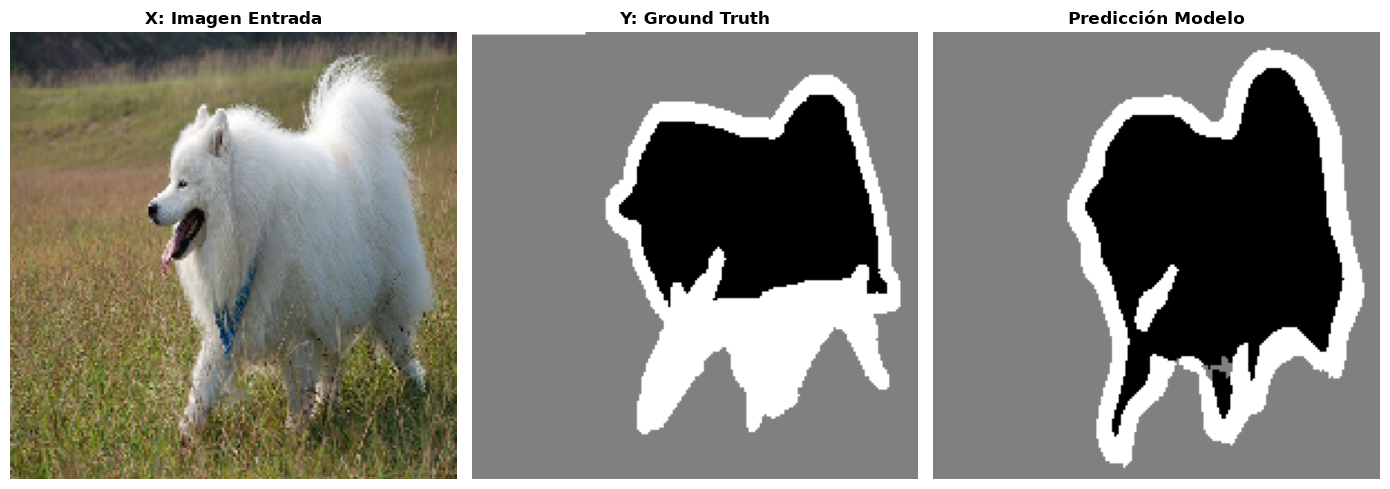

In [19]:
predicciones_batches = []
pred_loader = DataLoader(torch.from_numpy(val_input_imgs), batch_size=16, shuffle=False)

with torch.no_grad():
    for batch_imgs in pred_loader:
        batch_imgs = batch_imgs.to(device, non_blocking=True)
        logits = modelo_optimizado(batch_imgs)
        probs = torch.softmax(logits, dim=1)
        probs = probs.permute(0, 2, 3, 1).contiguous().cpu().numpy()
        predicciones_batches.append(probs)

predicciones = np.concatenate(predicciones_batches, axis=0)
print("Predicciones:", predicciones.shape)

# Probamos la visualización en una muestra específica
indice_muestra = 10
visualizar_prediccion(indice_muestra)

# Arquitectura U Net

In [ ]:
print("--- Construcción de la Arquitectura Alternativa (U-Net) con Keras ---")

def build_unet(img_size=(256, 256), num_classes=3):
    inputs = keras.Input(shape=img_size + (3,), name="Retinografia_Input_UNet")

    c1 = layers.Conv2D(32, 3, activation="relu", padding="same", name="Enc_Conv1_1")(inputs)
    c1 = layers.Conv2D(32, 3, activation="relu", padding="same", name="Enc_Conv1_2")(c1)
    p1 = layers.MaxPooling2D((2, 2), name="Enc_Pool1")(c1)

    c2 = layers.Conv2D(64, 3, activation="relu", padding="same", name="Enc_Conv2_1")(p1)
    c2 = layers.Conv2D(64, 3, activation="relu", padding="same", name="Enc_Conv2_2")(c2)
    p2 = layers.MaxPooling2D((2, 2), name="Enc_Pool2")(c2)

    c3 = layers.Conv2D(128, 3, activation="relu", padding="same", name="Enc_Conv3_1")(p2)
    c3 = layers.Conv2D(128, 3, activation="relu", padding="same", name="Enc_Conv3_2")(c3)
    p3 = layers.MaxPooling2D((2, 2), name="Enc_Pool3")(c3)

    b = layers.Conv2D(256, 3, activation="relu", padding="same", name="Bottleneck_Conv1")(p3)
    b = layers.Conv2D(256, 3, activation="relu", padding="same", name="Bottleneck_Conv2")(b)

    u3 = layers.Conv2DTranspose(128, 2, strides=2, padding="same", name="Dec_Up3")(b)
    concat3 = layers.Concatenate(name="Skip_Concat3")([u3, c3])
    d3 = layers.Conv2D(128, 3, activation="relu", padding="same", name="Dec_Conv3_1")(concat3)
    d3 = layers.Conv2D(128, 3, activation="relu", padding="same", name="Dec_Conv3_2")(d3)

    u2 = layers.Conv2DTranspose(64, 2, strides=2, padding="same", name="Dec_Up2")(d3)
    concat2 = layers.Concatenate(name="Skip_Concat2")([u2, c2])
    d2 = layers.Conv2D(64, 3, activation="relu", padding="same", name="Dec_Conv2_1")(concat2)
    d2 = layers.Conv2D(64, 3, activation="relu", padding="same", name="Dec_Conv2_2")(d2)

    u1 = layers.Conv2DTranspose(32, 2, strides=2, padding="same", name="Dec_Up1")(d2)
    concat1 = layers.Concatenate(name="Skip_Concat1")([u1, c1])
    d1 = layers.Conv2D(32, 3, activation="relu", padding="same", name="Dec_Conv1_1")(concat1)
    d1 = layers.Conv2D(32, 3, activation="relu", padding="same", name="Dec_Conv1_2")(d1)

    outputs = layers.Conv2D(num_classes, 1, activation="softmax", name="Mascara_Vascular_UNet")(d1)
    return keras.Model(inputs=inputs, outputs=outputs, name="UNet_Vasos_Retinianos_Keras")

modelo_unet_keras = build_unet(img_size=(200, 200), num_classes=3)
modelo_unet_keras.summary()

In [ ]:
modelo_unet_keras.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model_path_unet_keras = "models/oxford_unet.keras"
os.makedirs("models", exist_ok=True)
callbacks_unet_keras = [
    keras.callbacks.ModelCheckpoint(
        model_path_unet_keras,
        save_best_only=True,
        monitor="val_loss",
    )
]

print("U-Net Keras lista para entrenar")

In [ ]:
print("--- Entrenando U-Net con Keras ---")
history_unet_keras = modelo_unet_keras.fit(
    train_input_imgs,
    train_targets,
    epochs=15,
    batch_size=32,
    validation_data=(val_input_imgs, val_targets),
    callbacks=callbacks_unet_keras,
)

In [ ]:
modelo_unet_keras_entrenado = keras.models.load_model(model_path_unet_keras)
predicciones = modelo_unet_keras_entrenado.predict(val_input_imgs)

indice_muestra = 10
visualizar_prediccion(indice_muestra)

In [20]:
print("--- Construcción de la Arquitectura Alternativa (U-Net) en PyTorch ---")

class UNetSegmentation(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.pool3 = nn.MaxPool2d(2)
        self.bottleneck = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.up3 = nn.Upsample(scale_factor=2, mode="nearest")
        self.dec3 = nn.Sequential(
            nn.Conv2d(256 + 128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.up2 = nn.Upsample(scale_factor=2, mode="nearest")
        self.dec2 = nn.Sequential(
            nn.Conv2d(128 + 64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.up1 = nn.Upsample(scale_factor=2, mode="nearest")
        self.dec1 = nn.Sequential(
            nn.Conv2d(64 + 32, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.out = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):
        x = x.permute(0, 3, 1, 2).contiguous().float() / 255.0
        c1 = self.enc1(x)
        c2 = self.enc2(self.pool1(c1))
        c3 = self.enc3(self.pool2(c2))
        b = self.bottleneck(self.pool3(c3))
        d3 = self.up3(b)
        d3 = torch.cat([d3, c3], dim=1).contiguous()
        d3 = self.dec3(d3)
        d2 = self.up2(d3)
        d2 = torch.cat([d2, c2], dim=1).contiguous()
        d2 = self.dec2(d2)
        d1 = self.up1(d2)
        d1 = torch.cat([d1, c1], dim=1).contiguous()
        d1 = self.dec1(d1)
        return self.out(d1)

img_size = (200, 200)
num_classes = 3

modelo_unet = UNetSegmentation(num_classes=num_classes).to(device)
print(modelo_unet)
print("Parámetros entrenables:", sum(p.numel() for p in modelo_unet.parameters() if p.requires_grad))

--- Construcción de la Arquitectura Alternativa (U-Net) en PyTorch ---
UNetSegmentation(
  (enc1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (pool3): MaxPool2d(kernel_size=2, strid

In [21]:
# Configuración de entrenamiento para la U-Net en PyTorch
model_path = "models/oxford_unet_pytorch.pt"
os.makedirs("models", exist_ok=True)

criterion_unet = nn.CrossEntropyLoss()
optimizer_unet = torch.optim.Adam(modelo_unet.parameters(), lr=1e-3)

print("U-Net lista para entrenar en:", device)

U-Net lista para entrenar en: cuda


In [22]:
print("--- Iniciando entrenamiento de U-Net con PyTorch en GPU ---")

batch_size = 16
epochs = 15

train_dataset = TensorDataset(
    torch.from_numpy(train_input_imgs),
    torch.from_numpy(train_targets.squeeze(-1)).long(),
)
val_dataset = TensorDataset(
    torch.from_numpy(val_input_imgs),
    torch.from_numpy(val_targets.squeeze(-1)).long(),
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

history_unet = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}
best_val_loss = float("inf")

for epoch in range(epochs):
    modelo_unet.train()
    train_loss = 0.0
    train_correct = 0
    train_pixels = 0

    for batch_imgs, batch_masks in train_loader:
        batch_imgs = batch_imgs.to(device, non_blocking=True)
        batch_masks = batch_masks.to(device, non_blocking=True)

        optimizer_unet.zero_grad(set_to_none=True)
        logits = modelo_unet(batch_imgs)
        loss = criterion_unet(logits, batch_masks)
        loss.backward()
        optimizer_unet.step()

        train_loss += loss.item() * batch_imgs.size(0)
        train_correct += (logits.argmax(dim=1) == batch_masks).sum().item()
        train_pixels += batch_masks.numel()

    modelo_unet.eval()
    val_loss = 0.0
    val_correct = 0
    val_pixels = 0

    with torch.no_grad():
        for batch_imgs, batch_masks in val_loader:
            batch_imgs = batch_imgs.to(device, non_blocking=True)
            batch_masks = batch_masks.to(device, non_blocking=True)

            logits = modelo_unet(batch_imgs)
            loss = criterion_unet(logits, batch_masks)

            val_loss += loss.item() * batch_imgs.size(0)
            val_correct += (logits.argmax(dim=1) == batch_masks).sum().item()
            val_pixels += batch_masks.numel()

    epoch_loss = train_loss / len(train_dataset)
    epoch_acc = train_correct / train_pixels
    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = val_correct / val_pixels

    history_unet["loss"].append(epoch_loss)
    history_unet["accuracy"].append(epoch_acc)
    history_unet["val_loss"].append(epoch_val_loss)
    history_unet["val_accuracy"].append(epoch_val_acc)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(modelo_unet.state_dict(), model_path)

    print(
        f"Epoch {epoch + 1}/{epochs} - "
        f"loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} - "
        f"val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}"
    )

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("Mejor U-Net guardada en:", model_path)

--- Iniciando entrenamiento de U-Net con PyTorch en GPU ---


Epoch 1/15 - loss: 0.7989 - accuracy: 0.6599 - val_loss: 0.7000 - val_accuracy: 0.7131
Epoch 2/15 - loss: 0.6633 - accuracy: 0.7288 - val_loss: 0.5820 - val_accuracy: 0.7716


KeyboardInterrupt: 

32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 139ms/step


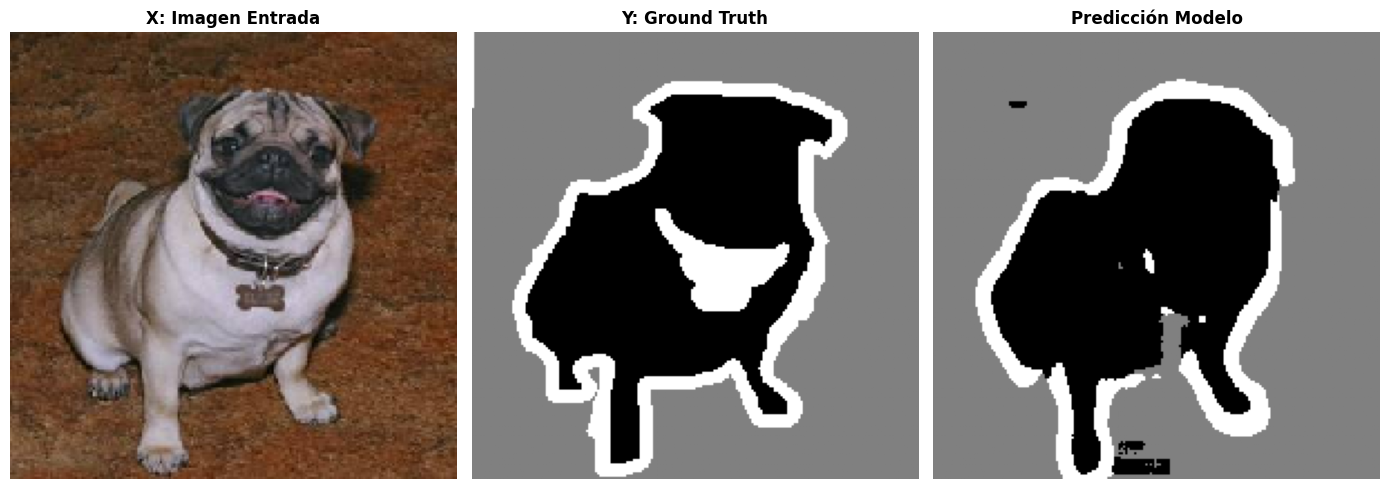

In [ ]:
# Carga de la mejor U-Net guardada
model_path = "models/oxford_unet_pytorch.pt"
modelo_optimizado = UNetSegmentation(num_classes=num_classes).to(device)
modelo_optimizado.load_state_dict(torch.load(model_path, map_location=device))
modelo_optimizado.eval()

predicciones_batches = []
pred_loader = DataLoader(torch.from_numpy(val_input_imgs), batch_size=16, shuffle=False)

with torch.no_grad():
    for batch_imgs in pred_loader:
        batch_imgs = batch_imgs.to(device, non_blocking=True)
        logits = modelo_optimizado(batch_imgs)
        probs = torch.softmax(logits, dim=1)
        probs = probs.permute(0, 2, 3, 1).contiguous().cpu().numpy()
        predicciones_batches.append(probs)

predicciones = np.concatenate(predicciones_batches, axis=0)
indice_muestra = 10
visualizar_prediccion(indice_muestra)

# SAM

In [3]:
# Preparación independiente para SAM con PyTorch y GPU NVIDIA
# Esta versión evita tensorflow-text, que no tiene rueda compatible con Windows nativo.
import importlib.util
import os
import subprocess
import sys

paquetes = {
    "transformers": "transformers",
    "PIL": "pillow",
}

faltantes = [
    paquete_pip
    for modulo, paquete_pip in paquetes.items()
    if importlib.util.find_spec(modulo) is None
]

if faltantes:
    print("Instalando paquetes faltantes:", ", ".join(faltantes))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *faltantes])
    print("Instalación terminada. Reinicia el kernel y ejecuta esta celda otra vez.")
else:
    print("Las librerías de SAM ya están instaladas.")

import torch
from transformers import SamModel, SamProcessor

print("PyTorch:", torch.__version__)
print("¿CUDA disponible para PyTorch?:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError(
        "PyTorch no detecta la GPU NVIDIA. Verifica el driver y selecciona el entorno ml3."
    )

device = torch.device("cuda")
print("GPU NVIDIA:", torch.cuda.get_device_name(0))
print("CUDA usada por PyTorch:", torch.version.cuda)
print("Dispositivo seleccionado:", device)

Las librerías de SAM ya están instaladas.
PyTorch: 2.14.0+cu126
¿CUDA disponible para PyTorch?: True
GPU NVIDIA: NVIDIA GeForce RTX 4050 Laptop GPU
CUDA usada por PyTorch: 12.6
Dispositivo seleccionado: cuda


In [6]:
# SAM Huge mediante Transformers/PyTorch
sam_model_id = "facebook/sam-vit-huge"
sam_processor = SamProcessor.from_pretrained(sam_model_id)
sam_model = SamModel.from_pretrained(sam_model_id).to(device)
sam_model.eval()

print("SAM cargado en:", device)
print("Parámetros:", sum(param.numel() for param in sam_model.parameters()))

Loading weights: 100%|██████████| 594/594 [00:02<00:00, 254.49it/s]


SAM cargado en: cuda
Parámetros: 641090864


In [9]:
# Reutiliza el modelo SAM cargado con Transformers/PyTorch.
# No uses keras_hub: requiere tensorflow y tensorflow-text.
model = sam_model

print("SAM activo:", type(model).__name__)
print(
    "Parámetros:",
    sum(parameter.numel() for parameter in model.parameters())
)

SAM activo: SamModel
Parámetros: 641090864


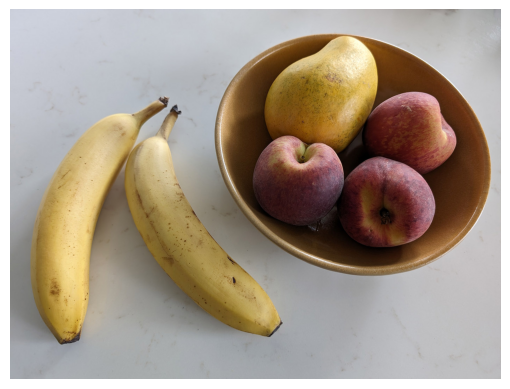

In [25]:
import keras
import matplotlib.pyplot as plt

# Downloads the image and returns the local file path
path = keras.utils.get_file(
    origin="https://s3.amazonaws.com/keras.io/img/book/fruits.jpg"
)
# Loads the image as a Python Imaging Library (PIL) object
pil_image = keras.utils.load_img(path)
# Turns the PIL object into a NumPy matrix
image_array = keras.utils.img_to_array(pil_image)

# Displays the NumPy matrix
plt.imshow(image_array.astype("uint8"))
plt.axis("off")
plt.show()

In [14]:
from keras import ops

image_size = (1024, 1024)

def resize_and_pad(x):
    return ops.image.resize(x, image_size, pad_to_aspect_ratio=True)

image = resize_and_pad(image_array)

In [15]:
import matplotlib.pyplot as plt
from keras import ops

def show_image(image, ax):
    ax.imshow(ops.convert_to_numpy(image).astype("uint8"))

def show_mask(mask, ax):
    color = np.array([30 / 255, 144 / 255, 255 / 255, 0.6])
    h, w, _ = mask.shape
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_points(points, ax):
    x, y = points[:, 0], points[:, 1]
    ax.scatter(x, y, c="green", marker="*", s=375, ec="white", lw=1.25)

def show_box(box, ax):
    box = box.reshape(-1)
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, ec="red", fc="none", lw=2))

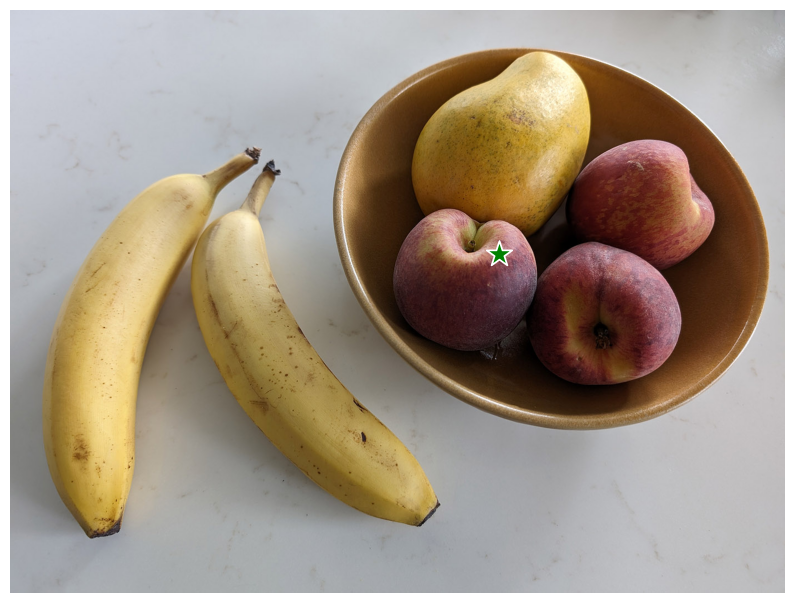

Tamaño de imagen: (1400, 1054)
Punto seleccionado dentro de la manzana: [[882.0, 442.0]]


In [27]:
# Selecciona un punto dentro de la manzana.
# Se calcula proporcionalmente para que funcione con el tamaño real de la imagen.
image_height, image_width = image_array.shape[:2]
input_point = np.array(
    [[int(image_width * 0.63), int(image_height * 0.42)]],
    dtype=np.float32,
)
input_label = np.array([1], dtype=np.int64)

plt.figure(figsize=(10, 10))
show_image(image_array, plt.gca())
show_points(input_point, plt.gca())
plt.axis("off")
plt.show()

print("Tamaño de imagen:", (image_width, image_height))
print("Punto seleccionado dentro de la manzana:", input_point.tolist())

In [28]:
# Preparar la entrada para Transformers y ejecutar SAM en la GPU.
# SamModel no tiene .predict(); en PyTorch se invoca como una función.
inputs = sam_processor(
    images=pil_image,
    input_points=[[input_point.tolist()]],
    input_labels=[[input_label.tolist()]],
    return_tensors="pt",
)
inputs = {nombre: valor.to(device) for nombre, valor in inputs.items()}

with torch.no_grad():
    outputs = sam_model(**inputs)

processed_masks = sam_processor.image_processor.post_process_masks(
    outputs.pred_masks.cpu(),
    inputs["original_sizes"].cpu(),
    inputs["reshaped_input_sizes"].cpu(),
)

print("Máscaras generadas:", processed_masks[0].shape)

Máscaras generadas: torch.Size([1, 3, 1054, 1400])


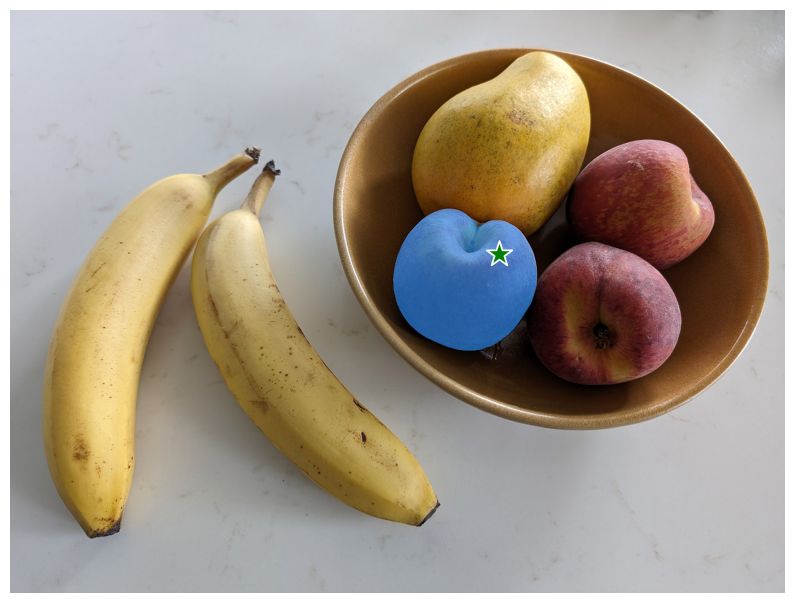

Máscara seleccionada: 0


In [33]:
# Elegir la máscara con la mayor puntuación de calidad de SAM.
best_index = outputs.iou_scores[0].argmax().item()
mask = processed_masks[0][0, best_index].numpy()
mask = np.expand_dims(mask, axis=-1)

plt.figure(figsize=(10, 10))
show_image(image_array, plt.gca())
show_mask(mask, plt.gca())
show_points(input_point, plt.gca())
plt.axis("off")
plt.show()

print("Máscara seleccionada:", best_index)

# Detectro2

In [ ]:
import cv2
import torch
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Detectron2 no tiene wheels para Windows y requiere compilar con MSVC + una versión
# exacta de CUDA/PyTorch; en su lugar usamos el Mask R-CNN de torchvision (misma
# arquitectura ResNet-50 + FPN, preentrenado en COCO), 100% compatible con el entorno ml3.
from torchvision.models.detection import maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights

## 1. Configuración del modelo: Mask R-CNN preentrenado (equivalente a Detectron2 en Windows)

En lugar del árbol de configuración YACS de Detectron2 (`cfg = get_cfg()` + `DefaultPredictor`), usamos la API equivalente de `torchvision`, que ofrece la misma arquitectura y el mismo flujo de inferencia.

### Desglose Línea por Línea

1. **`weights = MaskRCNN_ResNet50_FPN_Weights.DEFAULT`**: Equivale a `cfg.merge_from_file(...)` + `cfg.MODEL.WEIGHTS`: selecciona **Mask R-CNN** con red base **ResNet-50** y **FPN**, preentrenado en COCO.
2. **`box_score_thresh=0.5`**: Equivale a `cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5`. Todas las detecciones cuya probabilidad $\sigma(x)$ sea menor al $50\%$ se descartan.
3. **`device`**: Equivale a `cfg.MODEL.DEVICE`: usa la GPU NVIDIA (`cuda`) si está disponible, o cae a CPU.
4. **`model_maskrcnn.eval()`**: Equivale a construir el `DefaultPredictor`: coloca el modelo en modo inferencia, listo para redimensionar la imagen, convertirla a tensores en GPU, ejecutar el *forward pass* y aplicar **NMS** (supresión de no máximos) internamente.

In [6]:
# 1. Configuración del modelo Mask R-CNN preentrenado en COCO
weights = MaskRCNN_ResNet50_FPN_Weights.DEFAULT
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_maskrcnn = maskrcnn_resnet50_fpn(weights=weights, box_score_thresh=0.5)
model_maskrcnn.to(device).eval()

coco_categories = weights.meta["categories"]
print("Dispositivo:", device)
print("Umbral de confianza:", 0.5)

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to C:\Users\rodri/.cache\torch\hub\checkpoints\maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:39<00:00, 4.48MB/s] 


Dispositivo: cuda
Umbral de confianza: 0.5


## 2. Inferencia y Anatomía Interna de `outputs` e `Instances`

Al ejecutar `outputs = predictor(image)`, Detectron2 procesa la imagen en formato BGR (estándar de OpenCV) y devuelve un diccionario de Python. La clave principal para tareas de visión con localización es **`outputs["instances"]`**.

### ¿Qué ocurre en la celda de inferencia?

1. **`outputs = predictor(image)`**: Recibe la imagen y genera las predicciones.
2. **`instances = outputs["instances"].to("cpu")`**: Mueve las detecciones de la VRAM de la GPU a la memoria RAM de la CPU. Este paso es **estrictamente necesario** porque ni NumPy ni Matplotlib pueden manipular tensores que residan activamente en la VRAM.
3. **`instances.remove("pred_boxes")`**: Elimina dinámicamente el campo de las cajas delimitadoras del objeto `Instances`. Esto se hace para que el renderizador (`Visualizer`) dibuje **únicamente las máscaras de segmentación** sin sobreponer rectángulos visuales.
4. **`v.draw_instance_predictions(instances)`**: Recibe la imagen en formato RGB (`image[:, :, ::-1]`) y la información del catálogo de clases (`MetadataCatalog`) para superponer los polígonos de segmentación con colores distintos por cada instancia detectada.

---

### Estructura Interna del Objeto `Instances`

La clase `detectron2.structures.Instances` es un contenedor que almacena $N$ objetos detectados en la imagen. Cada campo interno es un tensor donde la primera dimensión es de tamaño $N$:

| Propiedad en `instances` | Tipo de Dato | Forma (Shape) | Descripción |
| :--- | :--- | :--- | :--- |
| **`pred_boxes`** | `Boxes` (PyTorch) | $(N, 4)$ | Coordenadas $[x_1, y_1, x_2, y_2]$ de cada caja delimitadora. |
| **`scores`** | `torch.Tensor` | $(N,)$ | Puntaje de confianza probabilística ($\sigma \in [0.0, 1.0]$) de cada detección. |
| **`pred_classes`** | `torch.Tensor` | $(N,)$ | Identificadores enteros del catálogo de clases ($0, 1, 2, \dots$). |
| **`pred_masks`** | `torch.Tensor` | $(N, H, W)$ | Máscaras binarias booleanas (`True`/`False`) a resolución completa de la imagen. |

## 2. Inferencia y visualización

Equivalente a `predictor(image)` de Detectron2 seguido de `Visualizer`: pasamos la imagen como tensor normalizado al modelo y dibujamos las cajas y etiquetas de las detecciones que superan el umbral de confianza.

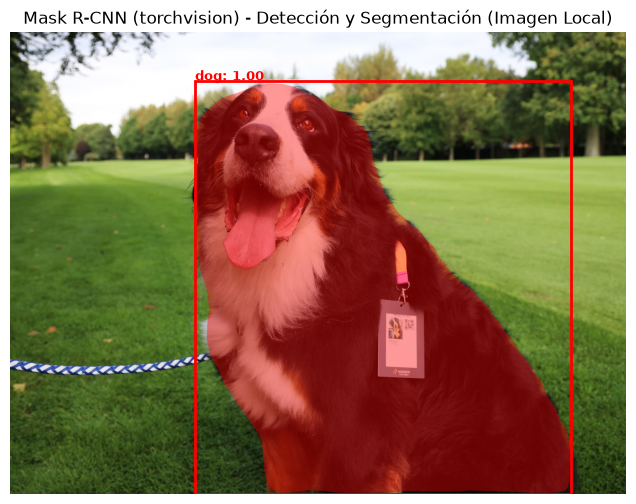

In [12]:
# 2. Carga defensiva del archivo local
input_image_path = Path("descarga.jpg")  # Ajustar a la ruta local

if not input_image_path.exists():
    print(f"❌ Error: No se encontró la imagen en {input_image_path.resolve()}")
else:
    image_bgr = cv2.imread(str(input_image_path))
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # 3. Inferencia con Mask R-CNN de torchvision (equivalente a predictor(image) de Detectron2)
    image_tensor = torch.from_numpy(image_rgb).permute(2, 0, 1).float() / 255.0
    image_tensor = image_tensor.to(device)

    with torch.no_grad():
        prediction = model_maskrcnn([image_tensor])[0]

    # 4. Renderizado visual: cajas, etiquetas y máscaras que superan el umbral de confianza
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(image_rgb)

    for box, label, score, mask in zip(
        prediction["boxes"], prediction["labels"], prediction["scores"], prediction["masks"]
    ):
        if score < 0.5:
            continue

        # Resaltar en rojo la clase "dog"; el resto de detecciones se muestran en verde
        es_perro = coco_categories[label] == "dog"
        color = "red" if es_perro else "lime"

        x1, y1, x2, y2 = box.cpu().numpy()
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor=color, fill=False)
        ax.add_patch(rect)
        ax.text(x1, y1 - 5, f"{coco_categories[label]}: {score:.2f}", color=color, fontsize=9, weight="bold")

        # Superponer la máscara de segmentación con el mismo color que la caja
        mask_np = mask[0].cpu().numpy() > 0.5
        colored_mask = np.zeros((*mask_np.shape, 4))
        colored_mask[mask_np] = [1, 0, 0, 0.4] if es_perro else [0, 1, 0, 0.4]
        ax.imshow(colored_mask)

    # 5. Despliegue en Matplotlib
    ax.set_title("Mask R-CNN (torchvision) - Detección y Segmentación (Imagen Local)")
    ax.axis("off")
    plt.show()

# YOLO

In [14]:
# Celda 1: Instalación de dependencias y descarga de imagen de prueba
#!pip install ultralytics opencv-python matplotlib requests

import cv2
import requests
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\rodri\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [18]:
# Descarga de una imagen de prueba estándar (URL directa a un archivo .jpg, no a una página web)
img_url = "https://ultralytics.com/images/bus.jpg"
img_bytes = requests.get(img_url).content
with open("sample.jpg", "wb") as f:
    f.write(img_bytes)

print("Entorno configurado e imagen 'sample.jpg' lista para inferencia.")

Entorno configurado e imagen 'sample.jpg' lista para inferencia.



image 1/1 c:\Users\rodri\OneDrive - Universidad Iberoamericana Len\Clases\7to Semestre\ML III\sample.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 21.7ms
Speed: 74.5ms preprocess, 21.7ms inference, 29.2ms postprocess per image at shape (1, 3, 640, 480)


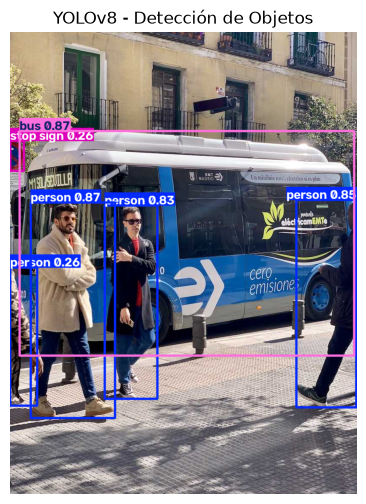

In [19]:
# Celda 2: Detección de Objetos (Bounding Boxes + Clases)
# Carga del modelo nano preentrenado en COCO
model_det = YOLO("yolov8n.pt")

# Inferencia
results_det = model_det("sample.jpg")

# Renderizado de bounding boxes (plot devuelve la imagen codificada en BGR)
res_det_bgr = results_det[0].plot()
res_det_rgb = cv2.cvtColor(res_det_bgr, cv2.COLOR_BGR2RGB)

# Visualización
plt.figure(figsize=(10, 6))
plt.imshow(res_det_rgb)
plt.title("YOLOv8 - Detección de Objetos")
plt.axis("off")
plt.show()


image 1/1 c:\Users\rodri\OneDrive - Universidad Iberoamericana Len\Clases\7to Semestre\ML III\sample.jpg: 640x480 4 persons, 1 bus, 1 skateboard, 29.8ms
Speed: 4.7ms preprocess, 29.8ms inference, 47.3ms postprocess per image at shape (1, 3, 640, 480)


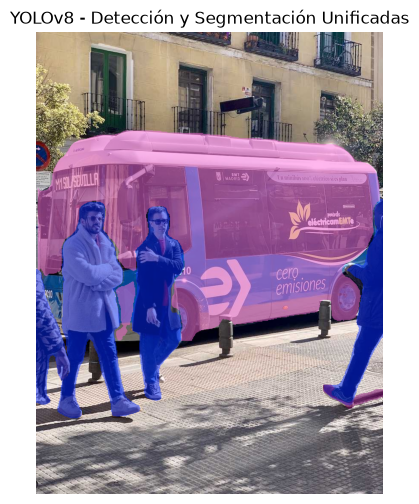

In [20]:
# Celda 3: Detección + Segmentación de Instancia
# Carga del modelo de segmentación
model_seg = YOLO("yolov8n-seg.pt")

# Inferencia
results_seg = model_seg("sample.jpg")

# Renderizado (combina bounding boxes, etiquetas y máscaras de píxeles)
res_seg_bgr = results_seg[0].plot(boxes=False, labels=False, masks=True)
res_seg_rgb = cv2.cvtColor(res_seg_bgr, cv2.COLOR_BGR2RGB)

# Visualización
plt.figure(figsize=(10, 6))
plt.imshow(res_seg_rgb)
plt.title("YOLOv8 - Detección y Segmentación Unificadas")
plt.axis("off")
plt.show()


image 1/1 c:\Users\rodri\OneDrive - Universidad Iberoamericana Len\Clases\7to Semestre\ML III\sample.jpg: 640x480 4 persons, 25.1ms
Speed: 3.3ms preprocess, 25.1ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 480)


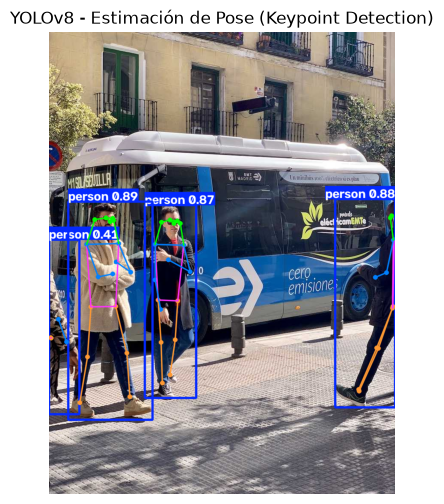

In [21]:
# Celda 4: Estimación de Pose (Landmarks / Keypoints)
# Carga del modelo de estimación de pose humano
model_pose = YOLO("yolov8n-pose.pt")

# Inferencia
results_pose = model_pose("sample.jpg")

# Renderizado (superpone el esqueleto y articulaciones detectadas)
res_pose_bgr = results_pose[0].plot()
res_pose_rgb = cv2.cvtColor(res_pose_bgr, cv2.COLOR_BGR2RGB)

# Visualización
plt.figure(figsize=(10, 6))
plt.imshow(res_pose_rgb)
plt.title("YOLOv8 - Estimación de Pose (Keypoint Detection)")
plt.axis("off")
plt.show()

In [2]:
!pip install roboflow

  Obtaining dependency information for roboflow from https://files.pythonhosted.org/packages/8e/dc/e14c34d1994d4fd11a94dc68e6ba4f75867fa45f8bd44fa90d85d18ee2bc/roboflow-1.5.0-py3-none-any.whl.metadata
  Obtaining dependency information for numpy<2.4,>=1.18.5 from https://files.pythonhosted.org/packages/2d/57/8aeaf160312f7f489dea47ab61e430b5cb051f59a98ae68b7133ce8fa06a/numpy-2.3.5-cp312-cp312-win_amd64.whl.metadata
     ---------------------------------------- 0.0/60.9 kB ? eta -:--:--
     ------ --------------------------------- 10.2/60.9 kB ? eta -:--:--
     ------------------- ------------------ 30.7/60.9 kB 435.7 kB/s eta 0:00:01
     -------------------------------------- 60.9/60.9 kB 649.9 kB/s eta 0:00:00
  Obtaining dependency information for opencv-python-headless>=4.10.0 from https://files.pythonhosted.org/packages/b8/88/763b967f7efd7226b82c9fae16d560cba049b1f0c036647e65c610fd636e/opencv_python_headless-5.0.0.93-cp37-abi3-win_amd64.whl.metadata
  Obtaining dependency informa


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from roboflow import Roboflow
rf = Roboflow(api_key="ROBOFLOW_")
project = rf.workspace("diabetic-1qcub").project("diabetic-retinopathy-3m3iz")
version = project.version(5)
dataset = version.download("png-mask-semantic")

ModuleNotFoundError: No module named 'roboflow'